# Antiygravty — Python GIS Procedural Pipeline

## المعمارية المعيارية (Modular Architecture)

هذا الدفتر ينفذ خط أنابيب كامل لتوليد المباني الإجرائية:

| المرحلة | الوصف | التقنية |
|---------|-------|---------|
| 1️⃣ Infrastructure | تثبيت المكتبات | `uv` |
| 2️⃣ GIS Layer | رسم المضلع على الخريطة | `leafmap` |
| 3️⃣ Geometry Layer | استخراج وتحويل الإحداثيات | `shapely` + `pyproj` |
| 4️⃣ Math Transform | الإزاحة المحلية (Local Offset) | Pure Math |
| 5️⃣ Procedural Core | توليد المبنى الإجرائي | `PyPRT` |
| 6️⃣ Visualization | العرض ثلاثي الأبعاد | `Three.js` |
| 7️⃣ Pipeline | تشغيل النظام بالكامل | `run_pipeline()` |

```
Sketch Polygon → GeoJSON → Shapely → UTM → Local Offset → PyPRT → glTF → Three.js
```

---
## 🛠️ المرحلة 1: إعداد البيئة (Infrastructure)
## Cell 1: Fast Dependency Installation via `uv`

نستخدم `uv` بدلاً من `pip` التقليدي لأنه أسرع بكثير في تثبيت الاعتمادات.

In [ ]:
# === Cell 1: Infrastructure — Fast Install with uv ===
# uv أسرع بكثير من pip ومناسب لبيئة Jupyter

# !uv pip install leafmap shapely pyproj pyprt ipywidgets

Audited 5 packages in 33ms


---
## 🗺️ المرحلة 2: طبقة GIS — الخريطة ورسم المضلع
## Cell 2: Interactive Map & Polygon Drawing

إنشاء خريطة تفاعلية مع نظام تخزين منظم للمضلعات المرسومة (`drawn_features`).

In [3]:
# === Cell 2: GIS Layer — Map & Polygon Storage ===

import leafmap
from IPython.display import display

# إنشاء الخريطة التفاعلية
m = leafmap.Map(center=[15.3694, 44.1910], zoom=16)

# لا نحتاج on_draw لأننا سنصل مباشرة للرسم لاحقاً من خلال m.draw_features

print("✅ الخريطة جاهزة — ارسم مضلعًا ثم شغّل الخلية التالية")
m

✅ الخريطة جاهزة — ارسم مضلعًا ثم شغّل الخلية التالية


Map(center=[15.3694, 44.191], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoo…

---
## 📐 المرحلة 3: طبقة المعالجة الهندسية
## Cell 3: Geometry Layer — Modular GeoJSON → Shapely → UTM

دوال مستقلة قابلة لإعادة الاستخدام:
- `get_polygon()` — تحويل GeoJSON إلى كائن Polygon
- `to_utm(polygon)` — تحويل الإحداثيات من WGS84 إلى UTM (بالمتر)

```
GeoJSON → Shapely Polygon → UTM Polygon (meters)
```

**لماذا UTM؟** لأن `1 unit = 1 meter` وهذا ما تتطلبه محركات النمذجة ثلاثية الأبعاد.

إحداثيات Lat/Lon الأصلية:
[(44.185704, 15.364293), (44.185704, 15.364971), (44.186187, 15.364971), (44.186187, 15.364293), (44.185704, 15.364293)]

✅ تم التحويل إلى UTM بنجاح (5 vertices):
  [0] x=412604.52, y=1698783.62
  [1] x=412656.36, y=1698783.42
  [2] x=412656.65, y=1698858.42
  [3] x=412604.81, y=1698858.62
  [4] x=412604.52, y=1698783.62


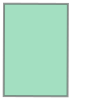

In [4]:
# === Cell 3: Geometry Layer — Extract & Transform ===

from shapely.geometry import shape, Polygon
from pyproj import Transformer
from IPython.display import display

# ── دالة استخراج المضلع ──
def get_polygon():
    """استخراج آخر مضلع مرسوم من الخريطة m وتحويله إلى Shapely Polygon."""
    if hasattr(m, 'draw_features') and len(m.draw_features) > 0:
        geojson = m.draw_features[-1]
        return shape(geojson["geometry"])
    
    print("⚠️ لا يوجد مضلع مرسوم — No polygon drawn yet")
    return None

# ── محول الإحداثيات ──
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32638", always_xy=True)

def to_utm(polygon):
    """تحويل الإحداثيات من WGS84 إلى UTM Zone 38N مع ضمان ترتيب CCW."""
    coords = list(polygon.exterior.coords)
    utm_coords = [transformer.transform(x, y) for x, y in coords]
    utm_polygon = Polygon(utm_coords)
    
    # ضمان ترتيب عكس عقارب الساعة (CCW)
    if not utm_polygon.exterior.is_ccw:
        utm_coords = list(utm_polygon.exterior.coords)[::-1]
        utm_polygon = Polygon(utm_coords)
    
    return utm_polygon

# ── اختبار الدوال ──
polygon = get_polygon()
if polygon:
    print("إحداثيات Lat/Lon الأصلية:")
    print(list(polygon.exterior.coords))
    
    utm_polygon = to_utm(polygon)
    utm_coords = list(utm_polygon.exterior.coords)
    
    print(f"\n✅ تم التحويل إلى UTM بنجاح ({len(utm_coords)} vertices):")
    for i, c in enumerate(utm_coords):
        print(f"  [{i}] x={c[0]:.2f}, y={c[1]:.2f}")
    
    display(utm_polygon)  # عرض شكل المضلع

---
## 🏛️ المرحلة 4: النواة الإجرائية + الإزاحة المحلية
## Cell 4: Procedural Core (PyPRT) + Local Offsetting

### الإزاحة المحلية (Local Offset)
لتجنب مشاكل الدقة في Three.js عند التعامل مع إحداثيات UTM الكبيرة:

$$X_{local} = X_{UTM} - X_{reference}$$
$$Y_{local} = Y_{UTM} - Y_{reference}$$

```
UTM Polygon → Local Offset → PyPRT CGA Rules → glTF
```

### المحرك الإجرائي
PyPRT يطبق قواعد CGA (مثل CityEngine) لتوليد المبنى تلقائياً.

In [5]:
# === Cell 4: Procedural Core + Local Offsetting ===

import pyprt, os, base64

try:
    pyprt.initialize_prt()
except Exception:
    pass  # Already initialized

def generate_building(utm_polygon):
    """
    توليد مبنى إجرائي من مضلع UTM.
    
    يتم تطبيق الإزاحة المحلية (Local Offset) قبل الإرسال إلى PyPRT
    لضمان دقة العرض في Three.js.
    """
    coords_2d = list(utm_polygon.exterior.coords)[:-1]
    
    # ── الإزاحة المحلية: X_local = X_UTM - X_ref ──
    center_x = sum(c[0] for c in coords_2d) / len(coords_2d)
    center_y = sum(c[1] for c in coords_2d) / len(coords_2d)
    
    flat_coords = []
    for x, y in coords_2d:
        flat_coords.extend([x - center_x, 0.0, y - center_y])
    
    # ── إعداد PyPRT ──
    initial_shape = pyprt.InitialShape(flat_coords)
    
    attributes = {
        "Usage": "Residential",
        "Mode": "Generate Facade",
        "Nbr_of_Floors": 8,
        "Standard_Floor_Height": 3.2,
        "Ground_Floor_Height": 5
    }
    
    RPK_PATH = r"C:\RPK\RuleFootprint.rpk"
    model_generator = pyprt.ModelGenerator([initial_shape])
    
    encoder = "com.esri.prt.codecs.GLTFEncoder"
    out_dir = os.path.join(os.getcwd(), "output_models")
    os.makedirs(out_dir, exist_ok=True)
    
    encoder_options = {
        "outputPath": out_dir,
        "baseName": "procedural_building"
    }
    
    # ── توليد المبنى ──
    model_generator.generate_model([attributes], RPK_PATH, encoder, encoder_options)
    
    # ── قراءة الملف وتحويله لـ Base64 ──
    glb_path = os.path.join(out_dir, "procedural_building_0.glb")
    with open(glb_path, "rb") as f:
        glb_data = f.read()
    
    print(f"✅ Model Generated with Local Offsetting!")
    print(f"   Reference Point: X={center_x:.2f}, Y={center_y:.2f}")
    print(f"   File size: {len(glb_data) / 1024:.1f} KB")
    
    return base64.b64encode(glb_data).decode('utf-8')

---
## 🌐 المرحلة 5: العرض ثلاثي الأبعاد (Three.js)
## Cell 5: 3D Visualization with Three.js

تحويل البيانات إلى تجربة بصرية باستخدام Three.js مباشرة داخل Jupyter.

```
glTF (Base64) → Three.js Viewer → Interactive 3D Scene
```

ميزات العارض:
- دعم Draco Compression & Meshopt
- إضاءة واقعية
- أدوات تحكم تفاعلية

In [6]:
# === Cell 5: 3D Visualization — Three.js Viewer ===

import os, webbrowser
from IPython.display import display, HTML

def create_viewer(model_b64):
    """
    إنشاء عارض Three.js وحقن النموذج فيه.
    يستخدم viewer_template.html كقالب أساسي.
    """
    template_path = os.path.join(os.getcwd(), 'viewer_template.html')
    with open(template_path, 'r', encoding='utf-8') as f:
        html_content = f.read()
    
    # حقن بيانات النموذج
    final_html = html_content.replace('%%MODEL_B64%%', model_b64)
    
    # حفظ الملف النهائي
    html_filename = 'viewer_full.html'
    with open(html_filename, 'w', encoding='utf-8') as f:
        f.write(final_html)
    
    # فتح في المتصفح
    full_path = os.path.abspath(html_filename)
    webbrowser.open('file:///' + full_path.replace(chr(92), '/'))
    
    # عرض رابط داخل الدفتر
    display(HTML("""
    <div style='border: 2px solid #6366f1; background: linear-gradient(135deg, #eef2ff, #e0e7ff); padding: 25px; border-radius: 12px; font-family: system-ui; text-align: center;'>
        <h2 style='color: #4f46e5; margin-top: 0;'>🎉 العارض جاهز — Viewer Ready!</h2>
        <p style='color: #333;'>Three.js Viewer مع دعم Draco/Meshopt</p>
        <div style='display: flex; gap: 10px; justify-content: center; flex-wrap: wrap; margin: 15px 0;'>
            <span style='background: #dbeafe; padding: 6px 12px; border-radius: 20px; font-size: 12px;'>🔧 Draco Compression</span>
            <span style='background: #dbeafe; padding: 6px 12px; border-radius: 20px; font-size: 12px;'>📦 Meshopt Decoder</span>
            <span style='background: #dbeafe; padding: 6px 12px; border-radius: 20px; font-size: 12px;'>▶ Animation Playback</span>
            <span style='background: #fef3c7; padding: 6px 12px; border-radius: 20px; font-size: 12px;'>🗺 خريطة تفاعلية</span>
        </div>
        <a href='viewer_full.html' target='_blank' 
           style='background: linear-gradient(135deg, #6366f1, #4f46e5); color: white; padding: 14px 28px; text-decoration: none; border-radius: 8px; font-weight: bold; display: inline-block; box-shadow: 0 4px 16px rgba(99,102,241,0.35);'>
           🏗 فتح العارض — Open Viewer
        </a>
    </div>
    """))
    print("✅ Viewer saved to:", os.path.abspath(html_filename))

---
## 🚀 المرحلة 6: تشغيل خط الأنابيب الكامل
## Cell 6: Execute Full Pipeline

دالة واحدة تسلسل جميع المراحل:

```
get_polygon() → to_utm() → generate_building() → create_viewer()
```

In [7]:
# === Cell 6: Full Pipeline Execution ===

def run_pipeline():
    """
    تشغيل خط الأنابيب الكامل:
    GIS Sketch → UTM → PyPRT → Three.js
    """
    print("═" * 50)
    print("🔄 Antiygravty Pipeline — Starting...")
    print("═" * 50)
    
    # المرحلة 1: قراءة الرسم من الخريطة
    print("\n📍 Step 1: Reading GIS Sketch...")
    polygon = get_polygon()
    if polygon is None:
        print("❌ Pipeline aborted — no polygon found.")
        return
    print(f"   Polygon with {len(list(polygon.exterior.coords))} vertices")
    
    # المرحلة 2: التحويل الرياضي إلى UTM
    print("\n📐 Step 2: Mathematical Transformation to UTM...")
    utm_poly = to_utm(polygon)
    print(f"   UTM Zone 38N — 1 unit = 1 meter")
    
    # المرحلة 3: التوليد الإجرائي
    print("\n🏛️ Step 3: Procedural Generation (PyPRT)...")
    gltf_b64 = generate_building(utm_poly)
    
    # المرحلة 4: العرض ثلاثي الأبعاد
    print("\n🌐 Step 4: Launching Three.js Viewer...")
    create_viewer(gltf_b64)
    
    print("\n" + "═" * 50)
    print("✅ Pipeline Complete!")
    print("═" * 50)

# ── تشغيل النظام ──
run_pipeline()

══════════════════════════════════════════════════
🔄 Antiygravty Pipeline — Starting...
══════════════════════════════════════════════════

📍 Step 1: Reading GIS Sketch...
   Polygon with 5 vertices

📐 Step 2: Mathematical Transformation to UTM...
   UTM Zone 38N — 1 unit = 1 meter

🏛️ Step 3: Procedural Generation (PyPRT)...
[PRT] [2026-03-13 10:07:10] [warning] CGB file contains warning 'Potentially problematic CGAC version 1.16 : major number smaller than current (2.10). Recompiling with current CGA Compiler is recommended.'
✅ Model Generated with Local Offsetting!
   Reference Point: X=412630.58, Y=1698821.02
   File size: 7451.9 KB

🌐 Step 4: Launching Three.js Viewer...


✅ Viewer saved to: c:\Users\hisham\Desktop\building_modeling\viewer_full.html

══════════════════════════════════════════════════
✅ Pipeline Complete!
══════════════════════════════════════════════════
